# aimio-py Examples

- **By:** [Erica Baldesarra, Johannes Bereiter-Payr](linkedin.com/in/erica-baldesarra-68966123a), 2026  
- **License:** CC-BY 
- **How to cite:** Cite the ORMIR_XCT publication: *Kuczynski et al., (2024). ORMIR_XCT: A Python package for high resolution peripheral quantitative computed tomography image processing. Journal of Open Source Software, 9(97), 6084, https://doi.org/10.21105/joss.06084*

---
# Aims

- This Jupyter Notebook provides an example of reading, writing, and viewing metadata of Scanco proprietary image types (i.e. AIM and ISQ)

  **Table of contents**  
  [Step 1: Importing](#importing)   
  [Step 2: Reading](#)  
  [Step 3: Writing](#)  
  [Step 4: Viewing Metadata](#)  
  [Step 5: Working with Processing Logs](#)


<a name="importing"></a>
## *Step 1: Importing*

Set up imports and file paths

In [1]:
from os import listdir
from os.path import join
from pathlib import Path

from py_aimio import read_aim, write_aim
import matplotlib.pyplot as plt
import numpy as np

In [4]:

# Specify the directory path
directory_path = Path(join('images', 'AIMIO_Examples'))

In [9]:
files = [directory_path / f for f in listdir(directory_path) if f.endswith('.AIM')]

<a name="reading"></a>
## *Step 2: Reading*

Read example `*.aim` files and show the contents.

In [97]:
def create_orthogonal_views(arr):
    center = [x // 2 for x in arr.shape]

    xy = arr[center[0], ...]
    xz = arr[:, center[1], :]
    yz = arr[:, :, center[2]]

    topview = np.concat([xy, yz.transpose(1, 0)], axis=1)
    botview = np.concat([xz, np.zeros((xz.shape[0], topview.shape[1] - xz.shape[1]))], axis=1)

    return np.concat([topview, botview], axis=0)


Plot the example images

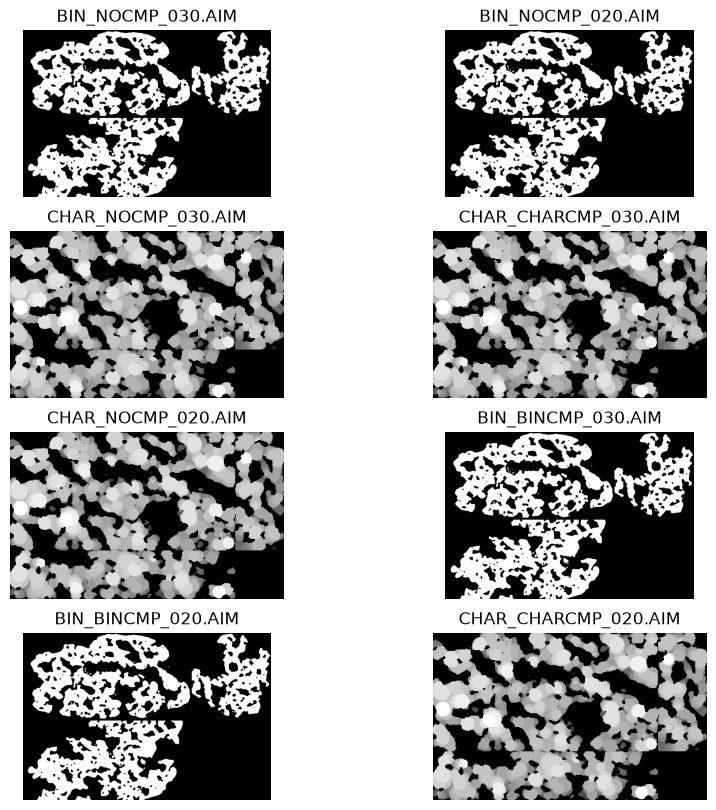

In [101]:
nrows, ncols = 4, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(10, 10))

metadata = []

for i, file in enumerate(files):
    arr, meta = read_aim(str(file))
    metadata.append(meta)

    ax[i // ncols, i % ncols].imshow(create_orthogonal_views(arr), cmap='gray')
    ax[i // ncols, i % ncols].set_title(f"{file.name}")
    ax[i // ncols, i % ncols].axis('off')

Print example metadata for one file: